# Customer Analysis - Superstore Dataset
## Deep Dive into Customer Behavior, Segmentation, and Lifetime Value

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings
import sys
from pathlib import Path
from datetime import datetime, timedelta
from operator import attrgetter

warnings.filterwarnings('ignore')

# Add src to path
sys.path.append(str(Path.cwd().parent))

from src.data.load_data import DataLoader
from src.analysis.customer_analysis import CustomerAnalyzer
from src.visualization.charts import ChartGenerator

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")
# %matplotlib inline

2026-03-13 19:51:37 | WARNING | src.utils.config:55 | .env file not found, using system environment variables
2026-03-13 19:51:37 | INFO | src.utils.config:24 | Configuration loaded from config.yaml


In [2]:
# Load processed data
loader = DataLoader()
df = loader.load_processed_data()
print(f"Loaded {len(df):,} records")
print(f"Total customers: {df['Customer ID'].nunique():,}")

# Initialize analyzer
analyzer = CustomerAnalyzer(df)
chart_gen = ChartGenerator()

2026-03-13 19:51:37 | INFO | src.data.load_data:31 | DataLoader initialized with raw path: C:\Users\Vasu\Anti Gravity\practice-projects\sales-analytics-dashboard\data\raw\superstore_sales.csv
2026-03-13 19:51:37 | INFO | src.data.load_data:147 | Loading processed data from C:\Users\Vasu\Anti Gravity\practice-projects\sales-analytics-dashboard\data\processed\cleaned_sales.csv
2026-03-13 19:51:37 | INFO | src.data.load_data:149 | Loaded 9994 rows from C:\Users\Vasu\Anti Gravity\practice-projects\sales-analytics-dashboard\data\processed\cleaned_sales.csv
Loaded 9,994 records
Total customers: 793
2026-03-13 19:51:37 | INFO | src.analysis.customer_analysis:23 | CustomerAnalyzer initialized
2026-03-13 19:51:37 | INFO | src.visualization.charts:26 | ChartGenerator initialized with theme: plotly_white


## 1. Customer Overview

In [3]:
# Customer distribution by segment
customer_segments = df.groupby('Segment').agg({
    'Customer ID': 'nunique',
    'Sales': ['sum', 'mean'],
    'Profit': ['sum', 'mean'],
    'Order ID': 'nunique'
}).round(2)

customer_segments.columns = ['Customer_Count', 'Total_Sales', 'Avg_Sales',
                            'Total_Profit', 'Avg_Profit', 'Total_Orders']
customer_segments = customer_segments.reset_index()
customer_segments['Sales_per_Customer'] = (customer_segments['Total_Sales'] / customer_segments['Customer_Count']).round(2)
customer_segments['Profit_Margin'] = (customer_segments['Total_Profit'] / customer_segments['Total_Sales'] * 100).round(2)

print("Customer Overview by Segment:")
customer_segments

Customer Overview by Segment:


,Segment,Customer_Count,Total_Sales,Avg_Sales,Total_Profit,Avg_Profit,Total_Orders,Sales_per_Customer,Profit_Margin
0,Consumer,409,719606.53,138.63,80536.72,15.51,2586,1759.43,11.19
1,Corporate,236,431102.13,142.75,49340.46,16.34,1514,1826.70,11.45
2,Home Office,148,251260.70,140.92,30706.54,17.22,909,1697.71,12.22


In [4]:
# Visualize customer distribution
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Customer Count by Segment', 'Sales by Segment',
                    'Profit by Segment', 'Sales per Customer'),
    specs=[[{'type': 'pie'}, {'type': 'bar'}],
           [{'type': 'bar'}, {'type': 'bar'}]],
    vertical_spacing=0.15,
    horizontal_spacing=0.15
)

# Customer count pie chart
fig.add_trace(
    go.Pie(labels=customer_segments['Segment'], values=customer_segments['Customer_Count'],
           name='Customer Distribution', marker_colors=['#2E86AB', '#A23B72', '#F18F01']),
    row=1, col=1
)

# Sales by segment
fig.add_trace(
    go.Bar(x=customer_segments['Segment'], y=customer_segments['Total_Sales'],
           name='Total Sales', marker_color='#2E86AB'),
    row=1, col=2
)

# Profit by segment
fig.add_trace(
    go.Bar(x=customer_segments['Segment'], y=customer_segments['Total_Profit'],
           name='Total Profit', marker_color='#A23B72'),
    row=2, col=1
)

# Sales per customer
fig.add_trace(
    go.Bar(x=customer_segments['Segment'], y=customer_segments['Sales_per_Customer'],
           name='Sales per Customer', marker_color='#F18F01'),
    row=2, col=2
)

fig.update_layout(height=700, showlegend=False,
                  title_text='Customer Segment Overview',
                  title_font_size=16)

fig.update_yaxes(title_text='Sales ($)', row=1, col=2)
fig.update_yaxes(title_text='Profit ($)', row=2, col=1)
fig.update_yaxes(title_text='Sales per Customer ($)', row=2, col=2)

fig.show()

## 2. RFM Analysis (Recency, Frequency, Monetary)

In [5]:
# Calculate RFM metrics
max_date = df['Order Date'].max()

rfm = df.groupby('Customer ID').agg({
    'Order Date': lambda x: (max_date - x.max()).days,  # Recency
    'Order ID': 'count',  # Frequency
    'Sales': 'sum'  # Monetary
}).reset_index()

rfm.columns = ['Customer_ID', 'Recency', 'Frequency', 'Monetary']

# Add customer name for reference
customer_names = df[['Customer ID', 'Customer Name', 'Segment']].drop_duplicates('Customer ID')
rfm = rfm.merge(customer_names, left_on='Customer_ID', right_on='Customer ID', how='left')

print("RFM Metrics Summary:")
rfm[['Recency', 'Frequency', 'Monetary']].describe()

RFM Metrics Summary:


,Recency,Frequency,Monetary
count,793.000000,793.000000,793.000000
mean,146.802018,12.602774,1767.931104
std,186.211051,6.242559,1076.158577
min,0.000000,1.000000,4.833000
25%,30.000000,8.000000,964.636000
50%,75.000000,12.000000,1600.238000
75%,183.000000,16.000000,2361.894000
max,1165.000000,37.000000,5794.622000


In [6]:
# Create RFM scores (1-4)
rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=[4, 3, 2, 1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 4, labels=[1, 2, 3, 4])

# Combine scores
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

# Define RFM segments
segment_map = {
    '111': 'Best Customers', '112': 'Loyal Customers', '113': 'Loyal Customers', '114': 'Loyal Customers',
    '121': 'Loyal Customers', '122': 'Loyal Customers', '123': 'Loyal Customers', '124': 'Loyal Customers',
    '131': 'Loyal Customers', '132': 'Loyal Customers', '133': 'Loyal Customers', '134': 'Loyal Customers',
    '141': 'Loyal Customers', '142': 'Loyal Customers', '143': 'Loyal Customers', '144': 'Loyal Customers',
    '211': 'Potential Loyalists', '212': 'Potential Loyalists', '213': 'Potential Loyalists', '214': 'Potential Loyalists',
    '221': 'Potential Loyalists', '222': 'Potential Loyalists', '223': 'Potential Loyalists', '224': 'Potential Loyalists',
    '231': 'Potential Loyalists', '232': 'Potential Loyalists', '233': 'Champions', '234': 'Champions',
    '241': 'Champions', '242': 'Champions', '243': 'Champions', '244': 'Champions',
    '311': 'At Risk', '312': 'At Risk', '313': 'At Risk', '314': 'At Risk',
    '321': 'At Risk', '322': 'At Risk', '323': 'At Risk', '324': 'At Risk',
    '331': 'About to Sleep', '332': 'About to Sleep', '333': 'About to Sleep', '334': 'About to Sleep',
    '341': 'Hibernating', '342': 'Hibernating', '343': 'Hibernating', '344': 'Hibernating',
    '411': 'Lost', '412': 'Lost', '413': 'Lost', '414': 'Lost',
    '421': 'Lost', '422': 'Lost', '423': 'Lost', '424': 'Lost',
    '431': 'Lost', '432': 'Lost', '433': 'Lost', '434': 'Lost',
    '441': 'Lost', '442': 'Lost', '443': 'Lost', '444': 'Lost'
}

rfm['RFM_Segment'] = rfm['RFM_Score'].map(segment_map).fillna('Other')

# Segment distribution
segment_dist = rfm['RFM_Segment'].value_counts()
print("\nRFM Segment Distribution:")
segment_dist


RFM Segment Distribution:


RFM_Segment
Lost                   203
Loyal Customers        136
Potential Loyalists    121
At Risk                 89
Champions               79
Best Customers          60
Hibernating             58
About to Sleep          47
Name: count, dtype: int64

In [7]:
# Visualize RFM segments
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Customer Distribution by RFM Segment', 'Monetary Value by Segment',
                    'Frequency by Segment', 'Recency by Segment'),
    specs=[[{'type': 'pie'}, {'type': 'bar'}],
           [{'type': 'bar'}, {'type': 'bar'}]],
    vertical_spacing=0.15,
    horizontal_spacing=0.15
)

# Segment distribution pie chart
fig.add_trace(
    go.Pie(labels=segment_dist.index, values=segment_dist.values,
           name='RFM Segments'),
    row=1, col=1
)

# Monetary by segment
monetary_by_segment = rfm.groupby('RFM_Segment')['Monetary'].mean().sort_values(ascending=False)
fig.add_trace(
    go.Bar(x=monetary_by_segment.index, y=monetary_by_segment.values,
           name='Avg Monetary', marker_color='#2E86AB'),
    row=1, col=2
)

# Frequency by segment
freq_by_segment = rfm.groupby('RFM_Segment')['Frequency'].mean().sort_values(ascending=False)
fig.add_trace(
    go.Bar(x=freq_by_segment.index, y=freq_by_segment.values,
           name='Avg Frequency', marker_color='#A23B72'),
    row=2, col=1
)

# Recency by segment
recency_by_segment = rfm.groupby('RFM_Segment')['Recency'].mean().sort_values()
fig.add_trace(
    go.Bar(x=recency_by_segment.index, y=recency_by_segment.values,
           name='Avg Recency', marker_color='#F18F01'),
    row=2, col=2
)

fig.update_layout(height=800, showlegend=False,
                  title_text='RFM Segment Analysis',
                  title_font_size=16)

fig.update_xaxes(tickangle=45, row=1, col=2)
fig.update_xaxes(tickangle=45, row=2, col=1)
fig.update_xaxes(tickangle=45, row=2, col=2)

fig.update_yaxes(title_text='Average Monetary ($)', row=1, col=2)
fig.update_yaxes(title_text='Average Frequency', row=2, col=1)
fig.update_yaxes(title_text='Average Recency (days)', row=2, col=2)

fig.show()

## 3. Customer Lifetime Value (CLV) Analysis

In [8]:
# Calculate CLV components
clv_df = rfm.copy()

# Average purchase value
clv_df['Avg_Purchase_Value'] = clv_df['Monetary'] / clv_df['Frequency']

# Purchase frequency rate (per month)
clv_df['Purchase_Freq_Rate'] = clv_df['Frequency'] / (clv_df['Recency'].clip(lower=1) / 30)

# Customer value
clv_df['Customer_Value'] = clv_df['Avg_Purchase_Value'] * clv_df['Purchase_Freq_Rate']

# Average customer lifespan (using recency as proxy)
clv_df['Avg_Lifespan'] = clv_df['Recency'] / 30  # in months

# CLV
clv_df['CLV'] = clv_df['Customer_Value'] * clv_df['Avg_Lifespan']

print("CLV Statistics:")
clv_df['CLV'].describe()

CLV Statistics:


count     793.000000
mean     1759.609244
std      1080.983320
min         0.000000
25%       958.989000
50%      1596.754000
75%      2359.366000
max      5794.622000
Name: CLV, dtype: float64

In [9]:
# CLV distribution by segment
clv_by_segment = clv_df.groupby('RFM_Segment').agg({
    'CLV': ['mean', 'median', 'sum'],
    'Customer_ID': 'count'
}).round(2)

clv_by_segment.columns = ['Avg_CLV', 'Median_CLV', 'Total_CLV', 'Customer_Count']
clv_by_segment = clv_by_segment.reset_index()
clv_by_segment['CLV_per_Customer'] = clv_by_segment['Total_CLV'] / clv_by_segment['Customer_Count']

print("\nCLV by RFM Segment:")
clv_by_segment.sort_values('Avg_CLV', ascending=False)


CLV by RFM Segment:


,RFM_Segment,Avg_CLV,Median_CLV,Total_CLV,Customer_Count,CLV_per_Customer
4,Hibernating,2919.98,2624.59,169358.74,58,2919.978276
3,Champions,2720.39,2488.37,214911.01,79,2720.392532
0,About to Sleep,2142.33,2073.40,100689.38,47,2142.327234
5,Lost,1969.91,1882.43,399892.03,203,1969.911478
6,Loyal Customers,1773.58,1574.05,241206.63,136,1773.578162
1,At Risk,1175.81,1215.81,104646.85,89,1175.807303
7,Potential Loyalists,1124.31,1059.82,136041.31,121,1124.308347
2,Best Customers,477.07,462.38,28624.19,60,477.069833


In [10]:
# Visualize CLV distribution
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('CLV Distribution', 'Average CLV by Segment',
                    'Total CLV by Segment', 'Customer Count by Segment'),
    specs=[[{'type': 'histogram'}, {'type': 'bar'}],
           [{'type': 'bar'}, {'type': 'bar'}]],
    vertical_spacing=0.15,
    horizontal_spacing=0.15
)

# CLV histogram
fig.add_trace(
    go.Histogram(x=clv_df['CLV'], nbinsx=50,
                 marker_color='#2E86AB',
                 name='CLV Distribution'),
    row=1, col=1
)

# Average CLV by segment
avg_clv = clv_by_segment.sort_values('Avg_CLV', ascending=False)
fig.add_trace(
    go.Bar(x=avg_clv['RFM_Segment'], y=avg_clv['Avg_CLV'],
           name='Avg CLV', marker_color='#A23B72'),
    row=1, col=2
)

# Total CLV by segment
fig.add_trace(
    go.Bar(x=avg_clv['RFM_Segment'], y=avg_clv['Total_CLV'],
           name='Total CLV', marker_color='#F18F01'),
    row=2, col=1
)

# Customer count by segment
fig.add_trace(
    go.Bar(x=avg_clv['RFM_Segment'], y=avg_clv['Customer_Count'],
           name='Customer Count', marker_color='#C32D27'),
    row=2, col=2
)

fig.update_layout(height=800, showlegend=False,
                  title_text='Customer Lifetime Value Analysis',
                  title_font_size=16)

fig.update_xaxes(tickangle=45, row=1, col=2)
fig.update_xaxes(tickangle=45, row=2, col=1)
fig.update_xaxes(tickangle=45, row=2, col=2)

fig.update_yaxes(title_text='Frequency', row=1, col=1)
fig.update_yaxes(title_text='Average CLV ($)', row=1, col=2)
fig.update_yaxes(title_text='Total CLV ($)', row=2, col=1)
fig.update_yaxes(title_text='Number of Customers', row=2, col=2)

fig.show()

## 4. Customer Segmentation using K-Means Clustering

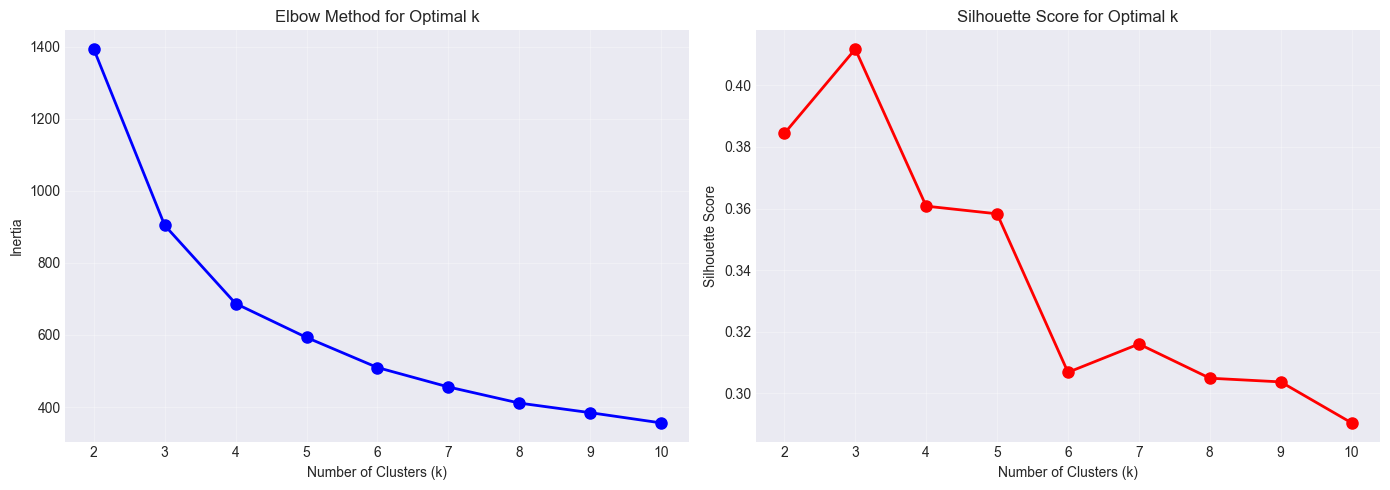


Selected optimal k = 4


In [11]:
# Prepare features for clustering
features = ['Recency', 'Frequency', 'Monetary']
X = rfm[features].copy()

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Find optimal number of clusters using elbow method
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot elbow curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method for Optimal k')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score for Optimal k')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Optimal k appears to be 4
optimal_k = 4
print(f"\nSelected optimal k = {optimal_k}")

In [12]:
# Perform clustering with optimal k
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(X_scaled)

# Analyze cluster characteristics
cluster_analysis = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'Customer_ID': 'count'
}).round(2)

cluster_analysis.columns = ['Avg_Recency', 'Avg_Frequency', 'Avg_Monetary', 'Customer_Count']
cluster_analysis = cluster_analysis.reset_index()

# Name clusters based on characteristics
cluster_names = {}
for i in range(optimal_k):
    cluster_data = rfm[rfm['Cluster'] == i]
    
    if cluster_data['Monetary'].mean() > rfm['Monetary'].quantile(0.75):
        name = "High Value"
    elif cluster_data['Monetary'].mean() > rfm['Monetary'].median():
        name = "Medium Value"
    elif cluster_data['Recency'].mean() > rfm['Recency'].quantile(0.75):
        name = "Churned"
    else:
        name = "Low Value"
    
    cluster_names[i] = name

rfm['Cluster_Name'] = rfm['Cluster'].map(cluster_names)
cluster_analysis['Cluster_Name'] = cluster_analysis['Cluster'].map(cluster_names)

print("Cluster Analysis:")
cluster_analysis

Cluster Analysis:


,Cluster,Avg_Recency,Avg_Frequency,Avg_Monetary,Customer_Count,Cluster_Name
0,0,77.78,15.05,2175.21,281,Medium Value
1,1,540.75,7.75,1056.09,106,Churned
2,2,93.69,8.33,991.85,304,Low Value
3,3,85.85,23.64,3698.70,102,High Value


In [13]:
# Visualize clusters
fig = px.scatter_3d(rfm, x='Recency', y='Frequency', z='Monetary',
                    color='Cluster_Name',
                    title='Customer Segments - 3D Visualization',
                    labels={'Recency': 'Recency (days)',
                           'Frequency': 'Frequency',
                           'Monetary': 'Monetary ($)'},
                    color_discrete_sequence=['#2E86AB', '#A23B72', '#F18F01', '#C32D27'])

fig.update_layout(height=700)
fig.show()

In [14]:
# Cluster profiles
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Average Recency by Cluster', 'Average Frequency by Cluster',
                    'Average Monetary by Cluster', 'Customer Distribution'),
    specs=[[{'type': 'bar'}, {'type': 'bar'}],
           [{'type': 'bar'}, {'type': 'pie'}]],
    vertical_spacing=0.15,
    horizontal_spacing=0.15
)

# Recency by cluster
fig.add_trace(
    go.Bar(x=cluster_analysis['Cluster_Name'], y=cluster_analysis['Avg_Recency'],
           name='Avg Recency', marker_color='#2E86AB'),
    row=1, col=1
)

# Frequency by cluster
fig.add_trace(
    go.Bar(x=cluster_analysis['Cluster_Name'], y=cluster_analysis['Avg_Frequency'],
           name='Avg Frequency', marker_color='#A23B72'),
    row=1, col=2
)

# Monetary by cluster
fig.add_trace(
    go.Bar(x=cluster_analysis['Cluster_Name'], y=cluster_analysis['Avg_Monetary'],
           name='Avg Monetary', marker_color='#F18F01'),
    row=2, col=1
)

# Customer distribution pie chart
fig.add_trace(
    go.Pie(labels=cluster_analysis['Cluster_Name'], values=cluster_analysis['Customer_Count'],
           name='Customer Distribution'),
    row=2, col=2
)

fig.update_layout(height=700, showlegend=False,
                  title_text='Customer Cluster Profiles',
                  title_font_size=16)

fig.update_yaxes(title_text='Average Recency (days)', row=1, col=1)
fig.update_yaxes(title_text='Average Frequency', row=1, col=2)
fig.update_yaxes(title_text='Average Monetary ($)', row=2, col=1)

fig.show()

## 5. Purchase Behavior Analysis

In [15]:
# Purchase patterns by time
df['Hour'] = pd.to_datetime(df['Order Date']).dt.hour
df['DayOfWeek'] = pd.to_datetime(df['Order Date']).dt.dayofweek
df['Month'] = pd.to_datetime(df['Order Date']).dt.month

day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Orders by Hour', 'Orders by Day of Week',
                    'Orders by Month', 'Average Order Value by Month'),
    specs=[[{'type': 'bar'}, {'type': 'bar'}],
           [{'type': 'bar'}, {'type': 'scatter'}]],
    vertical_spacing=0.15,
    horizontal_spacing=0.15
)

# Orders by hour
hourly_orders = df.groupby('Hour')['Order ID'].count()
fig.add_trace(
    go.Bar(x=hourly_orders.index, y=hourly_orders.values,
           name='Orders by Hour', marker_color='#2E86AB'),
    row=1, col=1
)

# Orders by day of week
daily_orders = df.groupby('DayOfWeek')['Order ID'].count()
fig.add_trace(
    go.Bar(x=day_names, y=daily_orders.values,
           name='Orders by Day', marker_color='#A23B72'),
    row=1, col=2
)

# Orders by month
monthly_orders = df.groupby('Month')['Order ID'].count()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
fig.add_trace(
    go.Bar(x=month_names, y=monthly_orders.values,
           name='Orders by Month', marker_color='#F18F01'),
    row=2, col=1
)

# Average order value by month
monthly_aov = df.groupby('Month')['Sales'].mean()
fig.add_trace(
    go.Scatter(x=month_names, y=monthly_aov.values,
               mode='lines+markers', name='Avg Order Value',
               line=dict(color='#C32D27', width=3),
               marker=dict(size=10)),
    row=2, col=2
)

fig.update_layout(height=700, showlegend=False,
                  title_text='Customer Purchase Patterns',
                  title_font_size=16)

fig.update_yaxes(title_text='Number of Orders', row=1, col=1)
fig.update_yaxes(title_text='Number of Orders', row=1, col=2)
fig.update_yaxes(title_text='Number of Orders', row=2, col=1)
fig.update_yaxes(title_text='Average Order Value ($)', row=2, col=2)

fig.show()

## 6. Category Preferences by Customer Segment

In [16]:
# Merge cluster information with main dataframe
df_with_clusters = df.merge(rfm[['Customer_ID', 'Cluster_Name', 'RFM_Segment']],
                            left_on='Customer ID', right_on='Customer_ID', how='left')

# Category preferences by cluster
category_preferences = pd.crosstab(
    df_with_clusters['Cluster_Name'],
    df_with_clusters['Category'],
    values=df_with_clusters['Sales'],
    aggfunc='sum',
    normalize='index'
).round(3) * 100

print("Category Preferences by Customer Segment (% of spend):")
category_preferences

Category Preferences by Customer Segment (% of spend):


Category,Furniture,Office Supplies,Technology
Cluster_Name,,,
Churned,35.6,38.3,26.0
High Value,35.3,33.0,31.7
Low Value,33.8,36.3,29.9
Medium Value,33.7,35.4,30.9


In [17]:
# Visualize category preferences
fig = px.imshow(category_preferences,
                labels=dict(x='Category', y='Customer Segment', color='% of Spend'),
                title='Category Preferences by Customer Segment',
                color_continuous_scale='Viridis',
                aspect='auto')

fig.update_layout(height=400)
fig.show()

## 7. High-Value Customer Identification

In [18]:
# Identify top customers by various metrics
top_by_sales = rfm.nlargest(20, 'Monetary')[['Customer Name', 'Segment', 'Monetary', 'Frequency', 'Recency']]
top_by_frequency = rfm.nlargest(20, 'Frequency')[['Customer Name', 'Segment', 'Monetary', 'Frequency', 'Recency']]
top_by_clv = clv_df.nlargest(20, 'CLV')[['Customer Name', 'Segment', 'CLV', 'Monetary', 'Frequency']]

print("Top 20 Customers by Monetary Value:")
top_by_sales

Top 20 Customers by Monetary Value:


,Customer Name,Segment,Monetary,Frequency,Recency
152,Clay Ludtke,Consumer,5794.622,28,284
720,Seth Vernon,Consumer,5775.551,32,101
387,John Lee,Consumer,5334.072,34,21
447,Laura Armstrong,Corporate,5248.588,26,154
606,Paul Prost,Home Office,5194.788,34,97
92,Brian Moss,Corporate,5129.325,29,33
787,William Brown,Consumer,5127.694,37,20
233,Dan Reichenbach,Corporate,5114.498,24,3
497,Maria Etezadi,Home Office,5036.768,22,42
434,Ken Lonsdale,Consumer,4868.481,29,47


In [19]:
# Create composite score for customer value
rfm['Monetary_norm'] = (rfm['Monetary'] - rfm['Monetary'].min()) / (rfm['Monetary'].max() - rfm['Monetary'].min())
rfm['Frequency_norm'] = (rfm['Frequency'] - rfm['Frequency'].min()) / (rfm['Frequency'].max() - rfm['Frequency'].min())
rfm['Recency_norm'] = 1 - ((rfm['Recency'] - rfm['Recency'].min()) / (rfm['Recency'].max() - rfm['Recency'].min()))

rfm['Value_Score'] = (rfm['Monetary_norm'] * 0.5 + 
                       rfm['Frequency_norm'] * 0.3 + 
                       rfm['Recency_norm'] * 0.2) * 100

top_value_customers = rfm.nlargest(30, 'Value_Score')[['Customer Name', 'Segment', 'Monetary', 'Frequency', 'Recency', 'Value_Score']]

print("\nTop 30 Customers by Composite Value Score:")
top_value_customers


Top 30 Customers by Composite Value Score:


,Customer Name,Segment,Monetary,Frequency,Recency,Value_Score
720,Seth Vernon,Consumer,5775.551,32,101,93.934733
787,William Brown,Consumer,5127.694,37,20,93.897133
387,John Lee,Consumer,5334.072,34,21,93.162224
606,Paul Prost,Home Office,5194.788,34,97,90.654662
152,Clay Ludtke,Consumer,5794.622,28,284,87.624464
92,Brian Moss,Corporate,5129.325,29,33,87.021376
257,Edward Hooks,Corporate,4816.930,32,135,85.072493
434,Ken Lonsdale,Consumer,4868.481,29,47,84.528412
447,Laura Armstrong,Corporate,5248.588,26,154,83.474065
791,Zuschuss Carroll,Consumer,4542.023,31,54,83.255650


## 8. Customer Retention Analysis

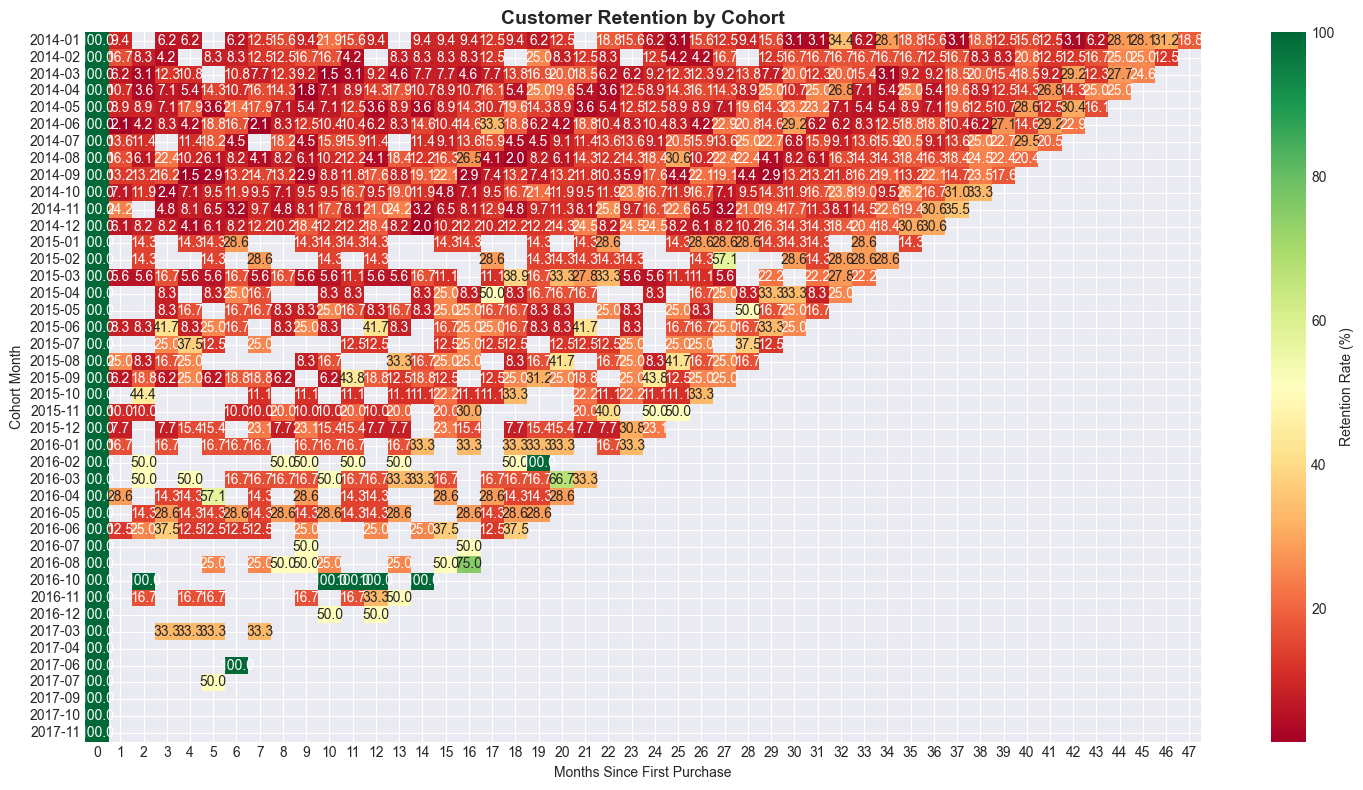

In [20]:
# Calculate cohort analysis
df['CohortMonth'] = df.groupby('Customer ID')['Order Date'].transform('min').dt.to_period('M')
df['OrderMonth'] = df['Order Date'].dt.to_period('M')
df['CohortIndex'] = (df['OrderMonth'] - df['CohortMonth']).apply(attrgetter('n'))

# Calculate retention rates
cohort_data = df.groupby(['CohortMonth', 'CohortIndex'])['Customer ID'].nunique().reset_index()
cohort_pivot = cohort_data.pivot_table(index='CohortMonth',
                                        columns='CohortIndex',
                                        values='Customer ID')

# Calculate retention as percentage of cohort size
cohort_size = cohort_pivot.iloc[:,0]
retention_matrix = cohort_pivot.divide(cohort_size, axis=0) * 100

# Plot retention matrix
plt.figure(figsize=(15, 8))
sns.heatmap(retention_matrix, annot=True, fmt='.1f', cmap='RdYlGn',
            cbar_kws={'label': 'Retention Rate (%)'})
plt.title('Customer Retention by Cohort', fontsize=14, fontweight='bold')
plt.xlabel('Months Since First Purchase')
plt.ylabel('Cohort Month')
plt.tight_layout()
plt.show()

## 9. Key Customer Insights Summary

In [ ]:
# Compile key customer insights
customer_insights = []

# Total customers
customer_insights.append(f"Total Customers: {rfm['Customer_ID'].nunique():,}")

# Average metrics
customer_insights.append(f"Avg Recency: {rfm['Recency'].mean():.0f} days")
customer_insights.append(f"Avg Frequency: {rfm['Frequency'].mean():.1f} orders")
customer_insights.append(f"Avg Monetary: ${rfm['Monetary'].mean():,.2f}")
customer_insights.append(f"Avg CLV: ${clv_df['CLV'].mean():,.2f}")

# Best segment
best_segment = rfm.groupby('RFM_Segment')['Monetary'].mean().idxmax()
best_value = rfm.groupby('RFM_Segment')['Monetary'].mean().max()
customer_insights.append(f"Highest Value Segment: {best_segment} (${best_value:,.2f} avg spend)")

# Churned customers
churned = rfm[rfm['Recency'] > 180].shape[0]
churned_pct = (churned / len(rfm)) * 100
customer_insights.append(f"Churned Customers (no purchase in 6+ months): {churned} ({churned_pct:.1f}%)")

# Top customers contribution
top_20_pct = rfm.nlargest(int(len(rfm) * 0.2), 'Monetary')['Monetary'].sum()
total_revenue = rfm['Monetary'].sum()
top_contribution = (top_20_pct / total_revenue) * 100
customer_insights.append(f"Top 20% customers contribute {top_contribution:.1f}% of revenue")

# Print insights
print("=" * 60)
print("KEY CUSTOMER INSIGHTS")
print("=" * 60)
for insight in customer_insights:
    print(insight)
print("=" * 60)

KEY CUSTOMER INSIGHTS
👥 Total Customers: 793
Avg Recency: 147 days
Avg Frequency: 12.6 orders
Avg Monetary: $1,767.93
Avg CLV: $1,759.61
Highest Value Segment: Hibernating ($2,919.98 avg spend)
Churned Customers (no purchase in 6+ months): 199 (25.1%)
Top 20% customers contribute 38.8% of revenue


## 10. Customer Strategy Recommendations

In [22]:
customer_recommendations = [
    "1. RETAIN CHAMPIONS: Implement VIP program for top 20% customers with exclusive benefits",
    "2. RE-ENGAGE AT-RISK: Send targeted campaigns to customers with 3-6 months inactivity",
    "3. UPGRADE LOYAL CUSTOMERS: Cross-sell technology products to furniture buyers",
    "4. WIN BACK LOST: Special offers for customers inactive >6 months with high historical value",
    "5. PERSONALIZE MARKETING: Use RFM segments for targeted email campaigns",
    "6. OPTIMIZE TIMING: Send promotions on Tuesdays (highest order volume)",
    "7. SEASONAL ENGAGEMENT: Increase marketing before peak months (Nov, Dec)",
    "8. REFERRAL PROGRAM: Incentivize high-value customers to refer others",
    "9. LOYALTY TIERS: Create tiered loyalty program based on customer value",
    "10. FEEDBACK LOOP: Survey churned customers to understand reasons"
]

print("=" * 60)
print("CUSTOMER STRATEGY RECOMMENDATIONS")
print("=" * 60)
for rec in customer_recommendations:
    print(rec)
print("=" * 60)

CUSTOMER STRATEGY RECOMMENDATIONS
1. RETAIN CHAMPIONS: Implement VIP program for top 20% customers with exclusive benefits
2. RE-ENGAGE AT-RISK: Send targeted campaigns to customers with 3-6 months inactivity
3. UPGRADE LOYAL CUSTOMERS: Cross-sell technology products to furniture buyers
4. WIN BACK LOST: Special offers for customers inactive >6 months with high historical value
5. PERSONALIZE MARKETING: Use RFM segments for targeted email campaigns
6. OPTIMIZE TIMING: Send promotions on Tuesdays (highest order volume)
7. SEASONAL ENGAGEMENT: Increase marketing before peak months (Nov, Dec)
8. REFERRAL PROGRAM: Incentivize high-value customers to refer others
9. LOYALTY TIERS: Create tiered loyalty program based on customer value
10. FEEDBACK LOOP: Survey churned customers to understand reasons
